In [1]:
# Add graphviz to path
import os

os.environ["PATH"] = os.environ["PATH"] + ":/opt/homebrew/bin"

# Imports
from datetime import date
from itertools import product

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vaxflux.covariates import (
    CovariateCategories,
    GaussianRandomWalkCovariate,
    PooledCovariate,
)
from vaxflux.curves import LogisticCurve
from vaxflux.data import sample_dataset
from vaxflux.dates import SeasonRange, daily_date_ranges
from vaxflux.uptake import SeasonalUptakeModel

In [2]:
logistic_curve = LogisticCurve()
logistic_curve

In [3]:
logistic_curve.parameters

('m', 'r', 's')

In [4]:
range_days = 0
season_ranges = [
    SeasonRange(
        season="2022/23",
        start_date=date(2022, 9, 5),
        end_date=date(2023, 1, 29),
    ),
    SeasonRange(
        season="2023/24",
        start_date=date(2023, 9, 4),
        end_date=date(2024, 1, 28),
    ),
    SeasonRange(
        season="2024/25",
        start_date=date(2024, 9, 2),
        end_date=date(2025, 1, 26),
    ),
]
date_ranges = daily_date_ranges(season_ranges, range_days=range_days)

In [5]:
sex_cov = CovariateCategories(covariate="sex", categories=("female", "male"))
age_cov = CovariateCategories(
    covariate="age",
    categories=("adult", "senior", "elderly"),
)

In [6]:
params = []

params_grid = {
    "2022/23": {
        "m": -0.5,
        "r": -3.2,
        "s": 40.0,
        "male": {
            "m": -0.05,
        },
        "senior": {
            "m": 1.0,
        },
        "elderly": {
            "m": 1.8,
        },
    },
    "2023/24": {
        "m": -0.55,
        "r": -3.1,
        "s": 42.5,
        "male": {
            "m": -0.06,
        },
        "senior": {
            "m": 1.05,
        },
        "elderly": {
            "m": 1.75,
        },
    },
    "2024/25": {
        "m": -0.51,
        "r": -3.3,
        "s": 41.0,
        "male": {
            "m": -0.04,
        },
        "senior": {
            "m": 1.1,
        },
        "elderly": {
            "m": 1.85,
        },
    },
}

for curve_param in logistic_curve.parameters:
    for season_range in season_ranges:
        for sex_category in sex_cov.categories:
            for age_category in age_cov.categories:
                season_params = params_grid[season_range.season]
                param_value = (
                    season_params[curve_param]
                    + season_params.get(sex_category, {}).get(curve_param, 0)
                    + season_params.get(age_category, {}).get(curve_param, 0)
                )
                params.append(
                    (
                        curve_param,
                        season_range.season,
                        sex_category,
                        age_category,
                        param_value,
                    ),
                )

[('m', '2022/23', 'female', 'adult', -0.5),
 ('m', '2022/23', 'female', 'senior', 0.5),
 ('m', '2022/23', 'female', 'elderly', 1.3),
 ('m', '2022/23', 'male', 'adult', -0.55),
 ('m', '2022/23', 'male', 'senior', 0.44999999999999996),
 ('m', '2022/23', 'male', 'elderly', 1.25),
 ('m', '2023/24', 'female', 'adult', -0.55),
 ('m', '2023/24', 'female', 'senior', 0.5),
 ('m', '2023/24', 'female', 'elderly', 1.2),
 ('m', '2023/24', 'male', 'adult', -0.6100000000000001),
 ('m', '2023/24', 'male', 'senior', 0.43999999999999995),
 ('m', '2023/24', 'male', 'elderly', 1.14),
 ('m', '2024/25', 'female', 'adult', -0.51),
 ('m', '2024/25', 'female', 'senior', 0.5900000000000001),
 ('m', '2024/25', 'female', 'elderly', 1.34),
 ('m', '2024/25', 'male', 'adult', -0.55),
 ('m', '2024/25', 'male', 'senior', 0.55),
 ('m', '2024/25', 'male', 'elderly', 1.3),
 ('r', '2022/23', 'female', 'adult', -3.2),
 ('r', '2022/23', 'female', 'senior', -3.2),
 ('r', '2022/23', 'female', 'elderly', -3.2),
 ('r', '2022/23

In [7]:
observations = sample_dataset(
    logistic_curve,
    season_ranges,
    date_ranges,
    [sex_cov, age_cov],
    params,
    0.002,
)
observations

,season,season_start_date,season_end_date,start_date,end_date,report_date,sex,age,type,value
0,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,adult,incidence,2.171651e-03
1,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,senior,incidence,3.810548e-03
2,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,elderly,incidence,6.153058e-03
3,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,male,adult,incidence,7.078232e-04
4,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,male,senior,incidence,3.809524e-03
...,...,...,...,...,...,...,...,...,...,...
2641,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,female,senior,incidence,8.004958e-05
2642,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,female,elderly,incidence,7.571909e-10
2643,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,male,adult,incidence,1.451985e-03
2644,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,male,senior,incidence,2.546029e-17


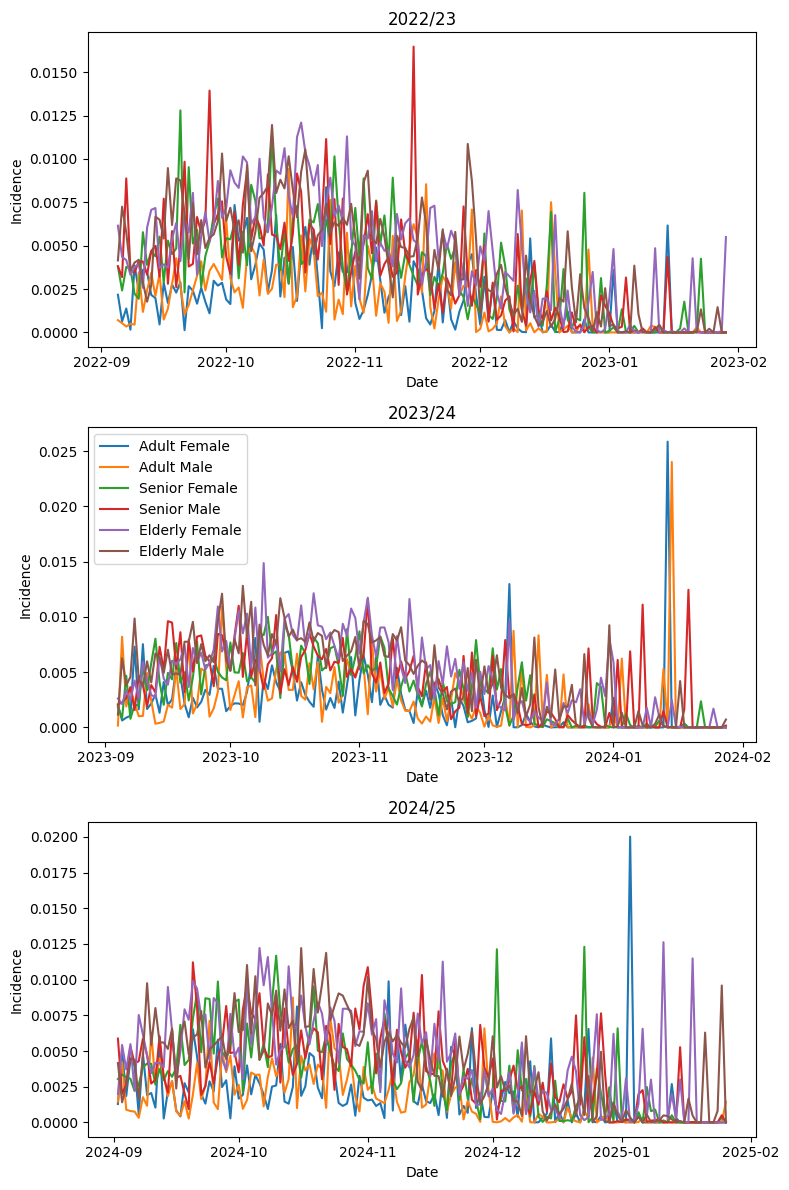

In [8]:
fig, axes = plt.subplots(
    nrows=len(season_ranges),
    ncols=1,
    figsize=(8, 12),
)

for i, season_range in enumerate(season_ranges):
    ax = axes[i]
    ax.set_title(season_range.season)
    ax.set_xlabel("Date")
    ax.set_ylabel("Incidence")
    for age_category in age_cov.categories:
        for sex_category in sex_cov.categories:
            observations_subset = observations[
                (observations["season"] == season_range.season)
                & (observations["age"] == age_category)
                & (observations["sex"] == sex_category)
            ]
            x = [
                el
                for pair in zip(
                    observations_subset["start_date"].tolist(),
                    observations_subset["end_date"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y = [
                el
                for pair in zip(
                    observations_subset["value"].tolist(),
                    observations_subset["value"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.plot(x, y, label=f"{age_category.title()} {sex_category.title()}")
    if i == (len(season_ranges) // 2):
        ax.legend()

fig.tight_layout()
plt.show()

In [9]:
observations_prevalence = observations.copy()
observations_prevalence = observations_prevalence.sort_values(
    [
        "start_date",
        "end_date",
        "season",
        "season_start_date",
        "season_end_date",
        "sex",
        "age",
    ],
)
observations_prevalence["prevalence"] = (
    observations_prevalence.groupby(["season", "sex", "age"])["value"]
    .cumsum()
    .reset_index()["value"]
)
observations_prevalence

,season,season_start_date,season_end_date,start_date,end_date,report_date,sex,age,type,value,prevalence
0,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,adult,incidence,2.171651e-03,0.002172
2,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,elderly,incidence,6.153058e-03,0.003811
1,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,female,senior,incidence,3.810548e-03,0.006153
3,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,male,adult,incidence,7.078232e-04,0.000708
5,2022/23,2022-09-05,2023-01-29,2022-09-05,2022-09-05,2022-09-05,male,elderly,incidence,4.150683e-03,0.003810
...,...,...,...,...,...,...,...,...,...,...,...
2642,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,female,elderly,incidence,7.571909e-10,0.487178
2641,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,female,senior,incidence,8.004958e-05,0.651234
2643,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,male,adult,incidence,1.451985e-03,0.256129
2645,2024/25,2024-09-02,2025-01-26,2025-01-26,2025-01-26,2025-01-26,male,elderly,incidence,1.332295e-21,0.541586


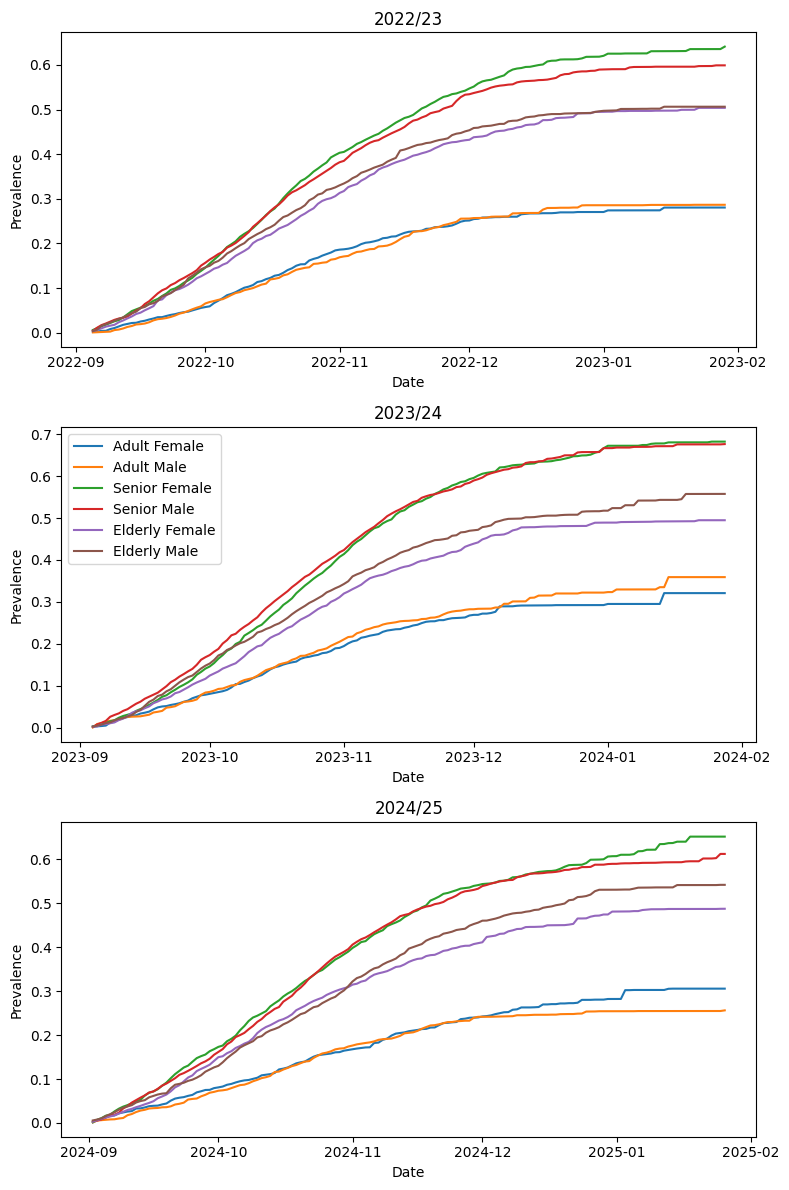

In [10]:
fig, axes = plt.subplots(
    nrows=len(season_ranges),
    ncols=1,
    figsize=(8, 12),
)

for i, season_range in enumerate(season_ranges):
    ax = axes[i]
    ax.set_title(season_range.season)
    ax.set_xlabel("Date")
    ax.set_ylabel("Prevalence")
    for age_category in age_cov.categories:
        for sex_category in sex_cov.categories:
            observations_subset = observations_prevalence[
                (observations_prevalence["season"] == season_range.season)
                & (observations_prevalence["age"] == age_category)
                & (observations_prevalence["sex"] == sex_category)
            ]
            x = [
                el
                for pair in zip(
                    observations_subset["start_date"].tolist(),
                    observations_subset["end_date"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y = [
                el
                for pair in zip(
                    observations_subset["prevalence"].tolist(),
                    observations_subset["prevalence"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.plot(x, y, label=f"{age_category.title()} {sex_category.title()}")
    if i == (len(season_ranges) // 2):
        ax.legend()

fig.tight_layout()
plt.show()

In [11]:
model = SeasonalUptakeModel(
    logistic_curve,
    [
        PooledCovariate(
            parameter="m",
            covariate=None,
            distribution="Normal",
            distribution_kwargs={"mu": -0.5, "sigma": 0.25},
        ),
        PooledCovariate(
            parameter="r",
            covariate=None,
            distribution="Normal",
            distribution_kwargs={"mu": -3.0, "sigma": 0.5},
        ),
        PooledCovariate(
            parameter="s",
            covariate=None,
            distribution="Normal",
            distribution_kwargs={"mu": 40.0, "sigma": 5.0},
        ),
        GaussianRandomWalkCovariate(
            parameter="m",
            covariate="age",
            init_mu=[1.0, 2.0],
            mu=2 * [0.0],
            sigma=2 * [0.25],
            eta=2.0,
        ),
        GaussianRandomWalkCovariate(
            parameter="m",
            covariate="sex",
            init_mu=-0.5,
            mu=0.0,
            sigma=0.1,
        ),
    ],
    observations=observations,
    covariate_categories=[sex_cov, age_cov],
    season_ranges=season_ranges,
    date_ranges=date_ranges,
    epsilon=0.01,
    # Custom keyword arguments
    constrain_prevalence=False,
    observation_sigma=1e-5,
    pooled_epsilon=True,
)
model

In [12]:
model.build(debug=False)

In [13]:
model.sample(
    tune=4000,
    draws=1000,
    chains=4,
)

Running window adaptation


There were 218 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


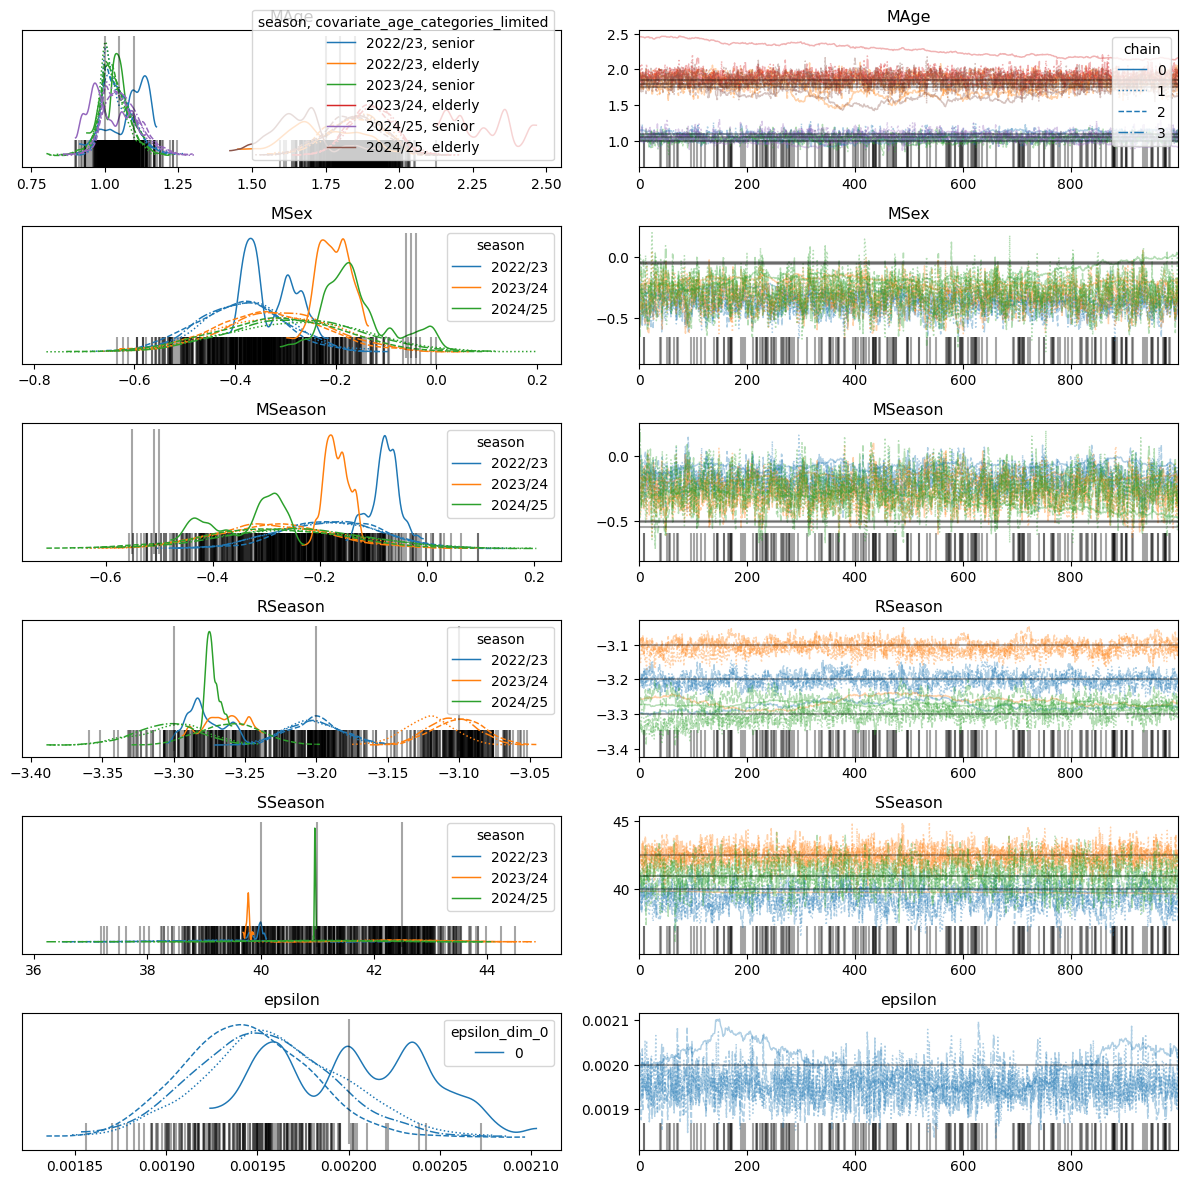

In [ ]:
az.plot_trace(
    model._trace,  # noqa: SLF001
    var_names=["MAge", "MSex", "MSeason", "RSeason", "SSeason", "epsilon"],
    lines=[
        ("MAge", {}, [1.0, 1.8, 1.05, 1.75, 1.1, 1.85]),
        ("MSex", {}, [-0.05, -0.06, -0.04]),
        ("MSeason", {}, [-0.5, -0.55, -0.51]),
        ("RSeason", {}, [-3.2, -3.1, -3.3]),
        ("SSeason", {}, [40.0, 42.5, 41.0]),
        ("epsilon", {}, [0.002]),
    ],
    legend=True,
    compact=True,
)
plt.tight_layout()

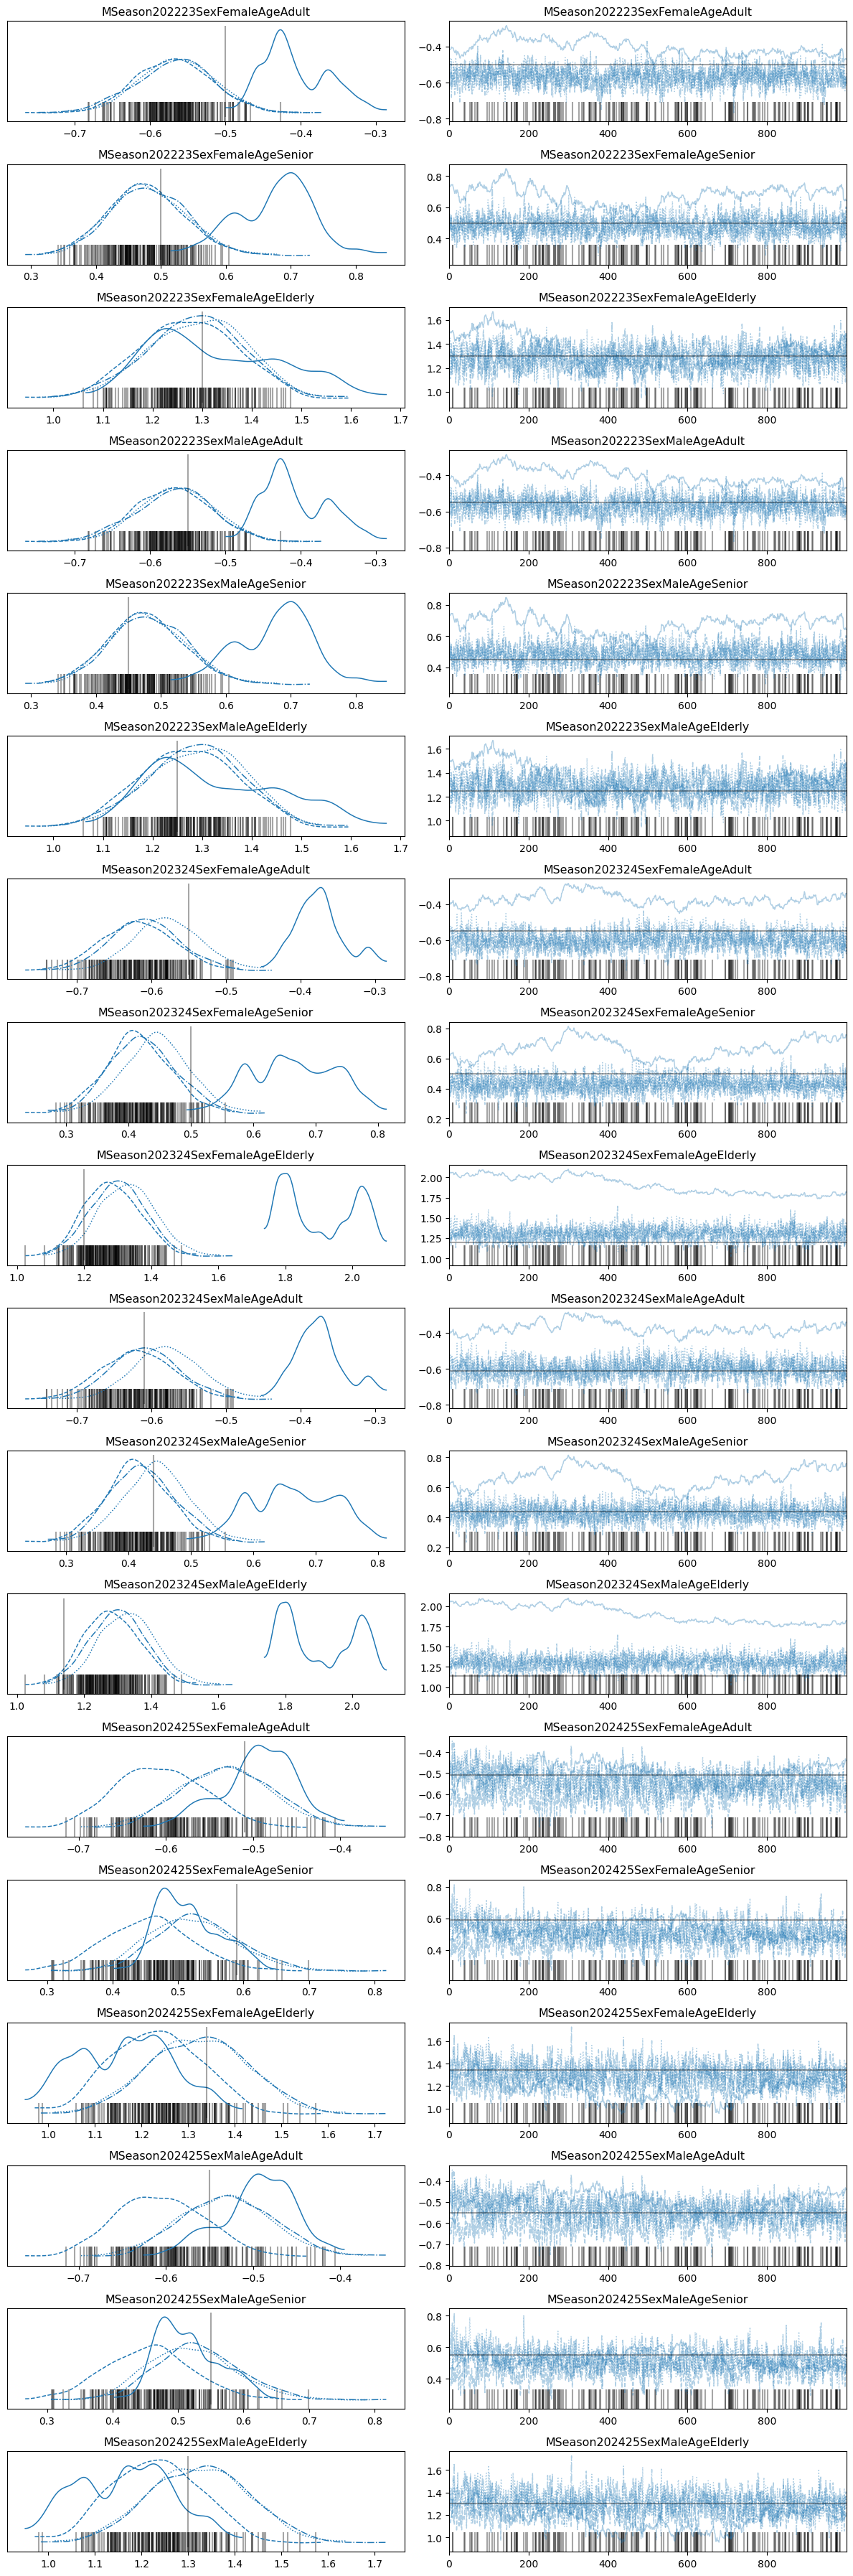

In [ ]:
var_names_and_lines = {
    (
        f"{p[0].title()}Season{p[1].replace('/', '').title()}"
        f"Sex{p[2].title()}Age{p[3].title()}"
    ): p[4]
    for p in params
    if p[0] == "m"
}

az.plot_trace(
    model._trace,  # noqa: SLF001
    var_names=list(var_names_and_lines.keys()),
    lines=[(k, {}, v) for k, v in var_names_and_lines.items()],
)
plt.tight_layout()

In [16]:
posterior_df = model.dataframe()
posterior_df.head(10)

,draw,chain,season,date,sex,age,type,value
0,0,0,2022/23,2022-09-05,female,adult,incidence,0.002169
1,0,0,2022/23,2022-09-06,female,adult,incidence,0.000639
2,0,0,2022/23,2022-09-07,female,adult,incidence,0.001370
3,0,0,2022/23,2022-09-08,female,adult,incidence,0.000164
4,0,0,2022/23,2022-09-09,female,adult,incidence,0.003847
5,0,0,2022/23,2022-09-10,female,adult,incidence,0.002397
6,0,0,2022/23,2022-09-11,female,adult,incidence,0.003633
7,0,0,2022/23,2022-09-12,female,adult,incidence,0.003497
8,0,0,2022/23,2022-09-13,female,adult,incidence,0.002166
9,0,0,2022/23,2022-09-14,female,adult,incidence,0.001997


In [17]:
posterior_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10584000 entries, 0 to 587999
Data columns (total 8 columns):
 #   Column  Dtype         
---  ------  -----         
 0   draw    int64         
 1   chain   int64         
 2   season  string        
 3   date    datetime64[ns]
 4   sex     string        
 5   age     string        
 6   type    string        
 7   value   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), string(4)
memory usage: 726.7 MB


In [18]:
posterior_df = (
    posterior_df.drop(columns=["type"])
    .rename(columns={"value": "incidence"})
    .sort_values(["draw", "chain", "season", "sex", "age", "date"])
)
posterior_df["prevalence"] = posterior_df.groupby(
    ["draw", "chain", "season", "sex", "age"],
)["incidence"].cumsum()
posterior_df

,draw,chain,season,date,sex,age,incidence,prevalence
0,0,0,2022/23,2022-09-05,female,adult,2.168832e-03,0.002169
1,0,0,2022/23,2022-09-06,female,adult,6.392653e-04,0.002808
2,0,0,2022/23,2022-09-07,female,adult,1.369775e-03,0.004178
3,0,0,2022/23,2022-09-08,female,adult,1.643747e-04,0.004342
4,0,0,2022/23,2022-09-09,female,adult,3.846575e-03,0.008189
...,...,...,...,...,...,...,...,...
587995,999,3,2024/25,2025-01-22,male,senior,5.219037e-10,0.540987
587996,999,3,2024/25,2025-01-23,male,senior,1.706550e-07,0.540987
587997,999,3,2024/25,2025-01-24,male,senior,6.019571e-08,0.540987
587998,999,3,2024/25,2025-01-25,male,senior,5.071451e-04,0.541494


In [19]:
range_days_to_freq = {
    6: "W",
}
if range_days > 0:
    if (freq := range_days_to_freq.get(range_days)) is None:
        msg = (
            f"Range days {range_days} not supported, "
            f"please add to `range_days_to_freq` dictionary."
        )
        raise RuntimeError(
            msg,
        )
    incidence_posterior_df = (
        posterior_df.groupby(
            [
                "chain",
                "draw",
                "season",
                pd.Grouper(key="date", freq=freq),
                "sex",
                "age",
            ],
        )["incidence"]
        .sum()
        .reset_index()
    )
incidence_posterior_df = (
    incidence_posterior_df if range_days > 0 else posterior_df
).rename(columns={"date": "end_date"})
incidence_posterior_df["start_date"] = incidence_posterior_df[
    "end_date"
] - pd.Timedelta(days=range_days)
incidence_posterior_df = (
    incidence_posterior_df.groupby(["season", "start_date", "end_date", "sex", "age"])[
        "incidence"
    ]
    .agg(
        [
            lambda x: np.quantile(x, 0.005),
            lambda x: np.quantile(x, 0.5),
            lambda x: np.quantile(x, 0.995),
        ],
    )
    .reset_index()
)
incidence_posterior_df = incidence_posterior_df.rename(
    columns={
        incidence_posterior_df.columns[-3]: "lower",
        incidence_posterior_df.columns[-2]: "median",
        incidence_posterior_df.columns[-1]: "upper",
    },
)
incidence_posterior_df

,season,start_date,end_date,sex,age,lower,median,upper
0,2022/23,2022-09-05,2022-09-05,female,adult,2.146953e-03,2.173166e-03,0.002195
1,2022/23,2022-09-05,2022-09-05,female,elderly,6.128953e-03,6.151973e-03,0.006178
2,2022/23,2022-09-05,2022-09-05,female,senior,3.786094e-03,3.808901e-03,0.003835
3,2022/23,2022-09-05,2022-09-05,male,adult,6.826723e-04,7.042661e-04,0.000733
4,2022/23,2022-09-05,2022-09-05,male,elderly,4.126121e-03,4.149464e-03,0.004175
...,...,...,...,...,...,...,...,...
2641,2024/25,2025-01-26,2025-01-26,female,elderly,1.671378e-27,2.165963e-08,0.000015
2642,2024/25,2025-01-26,2025-01-26,female,senior,5.514598e-08,7.453464e-05,0.000104
2643,2024/25,2025-01-26,2025-01-26,male,adult,1.292158e-08,1.448153e-03,0.001475
2644,2024/25,2025-01-26,2025-01-26,male,elderly,1.200881e-33,3.990775e-08,0.000014


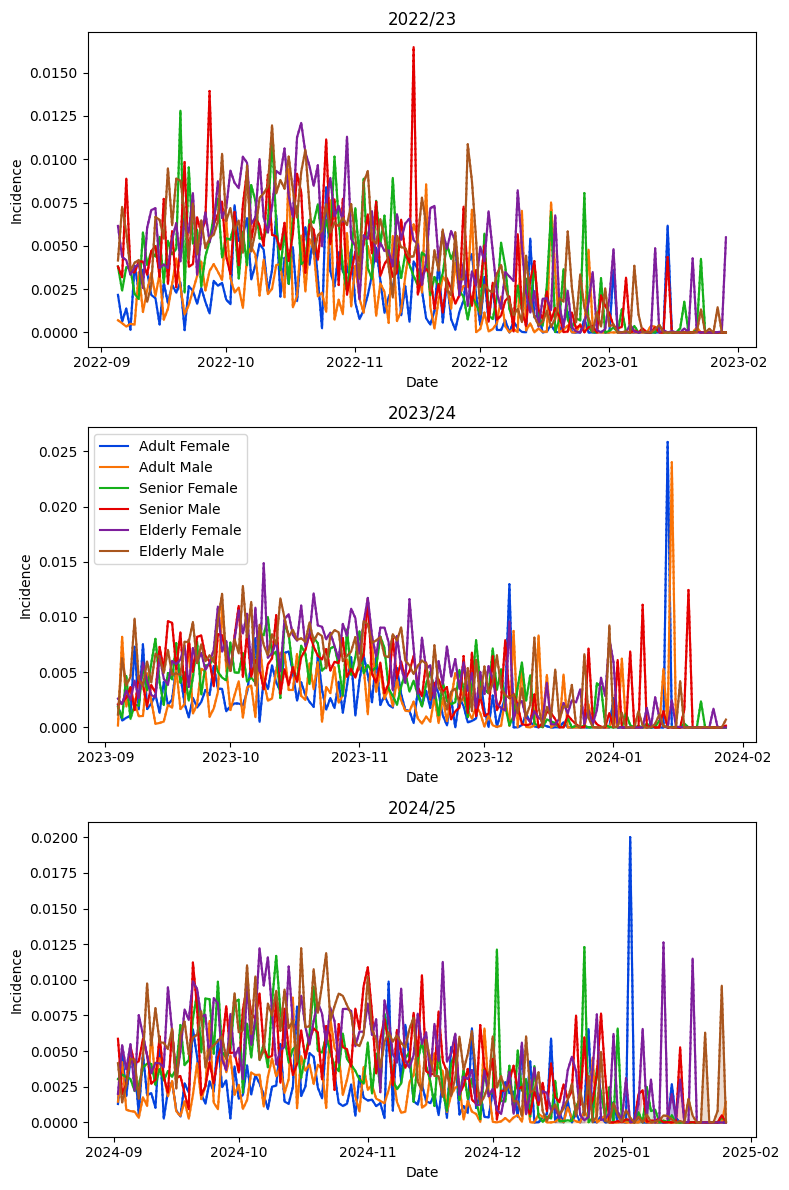

In [20]:
fig, axes = plt.subplots(
    nrows=len(season_ranges),
    ncols=1,
    figsize=(8, 12),
)

colors = (
    "xkcd:blue",
    "xkcd:orange",
    "xkcd:green",
    "xkcd:red",
    "xkcd:purple",
    "xkcd:sienna",
)
colors_map = {
    hash((age_category, sex_category)): color
    for color, (age_category, sex_category) in zip(
        colors,
        product(age_cov.categories, sex_cov.categories),
        strict=False,
    )
}

for i, season_range in enumerate(season_ranges):
    ax = axes[i]
    ax.set_title(season_range.season)
    ax.set_xlabel("Date")
    ax.set_ylabel("Incidence")
    for age_category in age_cov.categories:
        for sex_category in sex_cov.categories:
            color = colors_map[hash((age_category, sex_category))]
            observations_subset = observations[
                (observations["season"] == season_range.season)
                & (observations["age"] == age_category)
                & (observations["sex"] == sex_category)
            ]
            x = [
                el
                for pair in zip(
                    observations_subset["start_date"].tolist(),
                    observations_subset["end_date"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y = [
                el
                for pair in zip(
                    observations_subset["value"].tolist(),
                    observations_subset["value"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.plot(
                x,
                y,
                label=f"{age_category.title()} {sex_category.title()}",
                color=color,
                linestyle="-",
            )

            summary_posterior_subset = incidence_posterior_df[
                (incidence_posterior_df["season"] == season_range.season)
                & (incidence_posterior_df["age"] == age_category)
                & (incidence_posterior_df["sex"] == sex_category)
            ]
            x = [
                el
                for pair in zip(
                    summary_posterior_subset["start_date"].tolist(),
                    summary_posterior_subset["end_date"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y = [
                el
                for pair in zip(
                    summary_posterior_subset["median"].tolist(),
                    summary_posterior_subset["median"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.plot(x, y, color=color, linestyle=":")

            y1 = [
                el
                for pair in zip(
                    summary_posterior_subset["lower"].tolist(),
                    summary_posterior_subset["lower"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y2 = [
                el
                for pair in zip(
                    summary_posterior_subset["upper"].tolist(),
                    summary_posterior_subset["upper"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.fill_between(x, y1, y2, color=color, alpha=0.2)
    if i == (len(season_ranges) // 2):
        ax.legend()

fig.tight_layout()
plt.show()

In [21]:
prevalence_posterior_df = (
    posterior_df.groupby(["season", "date", "sex", "age"])["prevalence"]
    .agg(
        [
            lambda x: np.quantile(x, 0.005),
            lambda x: np.quantile(x, 0.5),
            lambda x: np.quantile(x, 0.995),
        ],
    )
    .reset_index()
)
prevalence_posterior_df = prevalence_posterior_df.rename(
    columns={
        prevalence_posterior_df.columns[-3]: "lower",
        prevalence_posterior_df.columns[-2]: "median",
        prevalence_posterior_df.columns[-1]: "upper",
    },
)
prevalence_posterior_df

,season,date,sex,age,lower,median,upper
0,2022/23,2022-09-05,female,adult,0.002147,0.002173,0.002195
1,2022/23,2022-09-05,female,elderly,0.006129,0.006152,0.006178
2,2022/23,2022-09-05,female,senior,0.003786,0.003809,0.003835
3,2022/23,2022-09-05,male,adult,0.000683,0.000704,0.000733
4,2022/23,2022-09-05,male,elderly,0.004126,0.004149,0.004175
...,...,...,...,...,...,...,...
2641,2024/25,2025-01-26,female,elderly,0.645518,0.651179,0.651517
2642,2024/25,2025-01-26,female,senior,0.477871,0.487105,0.487423
2643,2024/25,2025-01-26,male,adult,0.251132,0.256072,0.256389
2644,2024/25,2025-01-26,male,elderly,0.589073,0.611855,0.612186


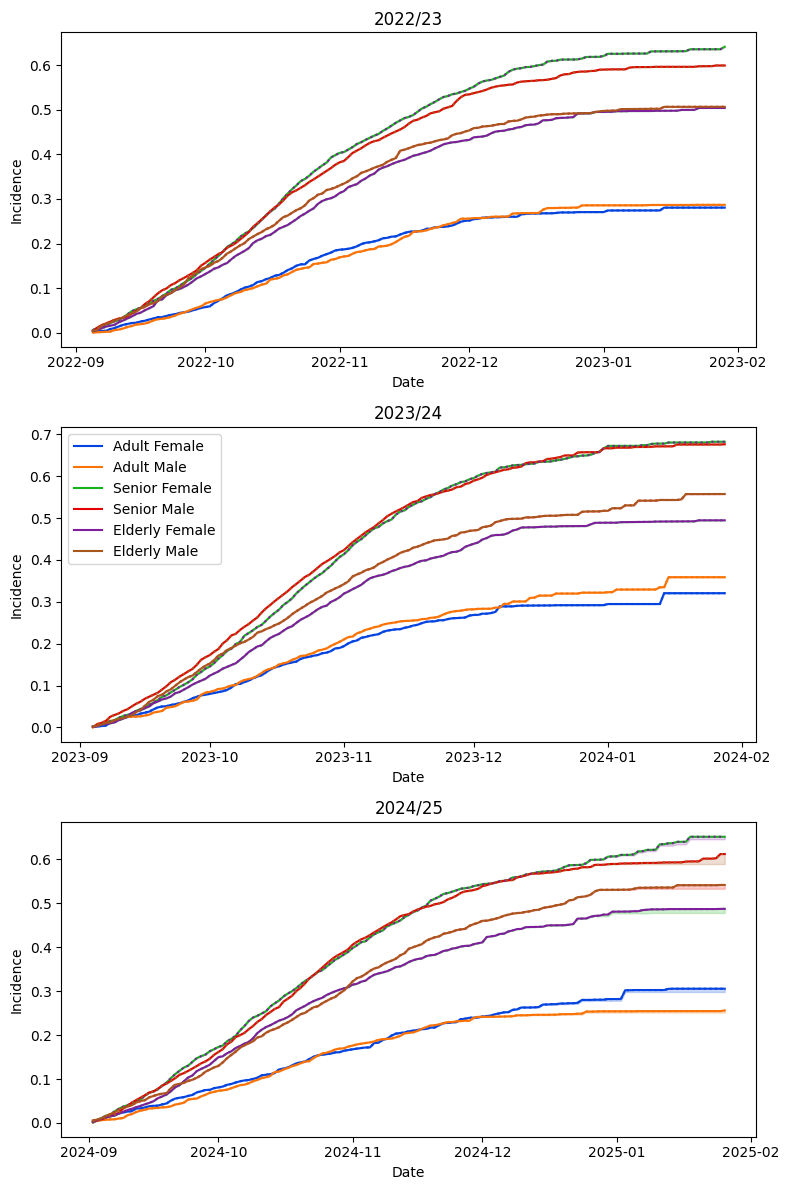

In [22]:
fig, axes = plt.subplots(
    nrows=len(season_ranges),
    ncols=1,
    figsize=(8, 12),
)

colors = (
    "xkcd:blue",
    "xkcd:orange",
    "xkcd:green",
    "xkcd:red",
    "xkcd:purple",
    "xkcd:sienna",
)
colors_map = {
    hash((age_category, sex_category)): color
    for color, (age_category, sex_category) in zip(
        colors,
        product(age_cov.categories, sex_cov.categories),
        strict=False,
    )
}

for i, season_range in enumerate(season_ranges):
    ax = axes[i]
    ax.set_title(season_range.season)
    ax.set_xlabel("Date")
    ax.set_ylabel("Incidence")
    for age_category in age_cov.categories:
        for sex_category in sex_cov.categories:
            color = colors_map[hash((age_category, sex_category))]
            observations_subset = observations_prevalence[
                (observations_prevalence["season"] == season_range.season)
                & (observations_prevalence["age"] == age_category)
                & (observations_prevalence["sex"] == sex_category)
            ]
            x = [
                el
                for pair in zip(
                    observations_subset["start_date"].tolist(),
                    observations_subset["end_date"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            y = [
                el
                for pair in zip(
                    observations_subset["prevalence"].tolist(),
                    observations_subset["prevalence"].tolist(),
                    strict=False,
                )
                for el in pair
            ]
            ax.plot(
                x,
                y,
                label=f"{age_category.title()} {sex_category.title()}",
                color=color,
                linestyle="-",
            )

            summary_posterior_subset = prevalence_posterior_df[
                (prevalence_posterior_df["season"] == season_range.season)
                & (prevalence_posterior_df["age"] == age_category)
                & (prevalence_posterior_df["sex"] == sex_category)
            ]

            x = summary_posterior_subset["date"].tolist()
            y = summary_posterior_subset["median"].tolist()
            ax.plot(x, y, color=color, linestyle=":")

            y1 = summary_posterior_subset["lower"].tolist()
            y2 = summary_posterior_subset["upper"].tolist()
            ax.fill_between(x, y1, y2, color=color, alpha=0.2)
    if i == (len(season_ranges) // 2):
        ax.legend()

fig.tight_layout()
plt.show()